### Task 1: Potential problems in linear regression

**Issue 1: Correlation of Error Terms**
***

The issue with this is that linear models assume that error terms are not correlated, and because of this the models reported standard errors are likely to become artifically small if the errors are correlated. This is important as it will make the model seem much more precise or accurate than it actually is, leading to potentially inaccurate interpretations. This can be detected by plotting the data residuals as a function of x and seeing if there is tracking in the residuals.

A question that thought of while reading that you couldn’t answer from the text alone, and the answer you investigated
While reading I wondered what the method for detection would be with non-timeseries data, as they only covered that. I found that for grouped data it is common to plot the residuals seperately for each group and see if there is tracking. 

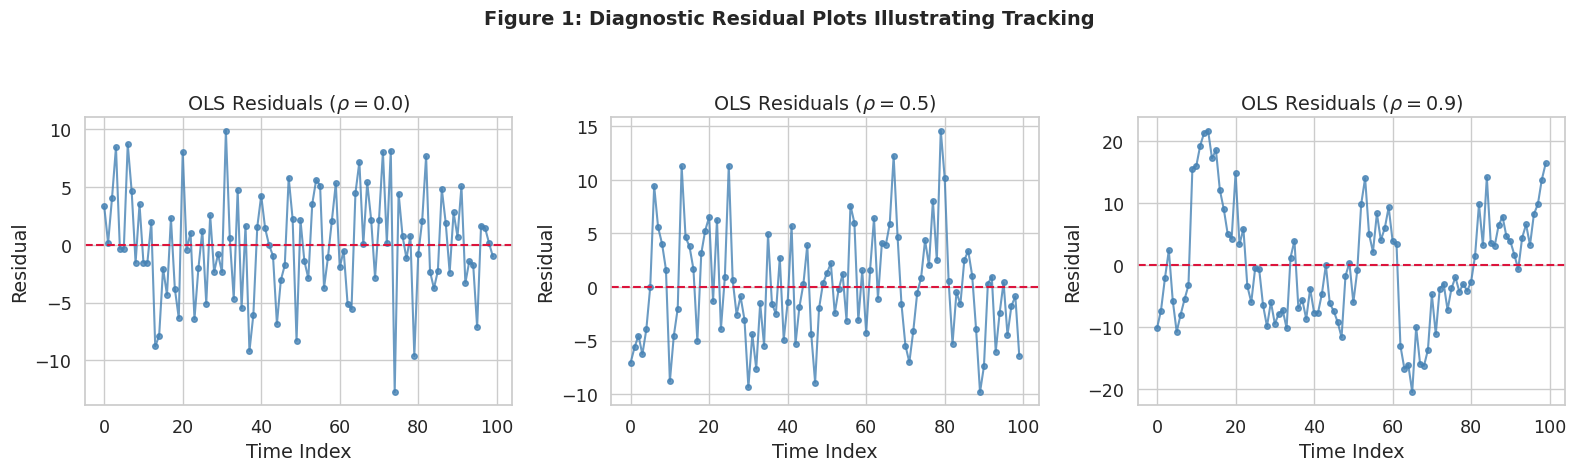

Table 1: Impact of Error Correlation on Inference for β₁ (Time Slope)
Correlation ($\rho$) Naive OLS SE HAC Corrected SE Naive OLS p-value HAC Corrected p-value
                 0.0       0.0158           0.0170        1.3586e-81            0.0000e+00
                 0.5       0.0178           0.0253        1.3527e-76            0.0000e+00
                 0.9       0.0323           0.0775        2.3440e-44            1.8110e-25


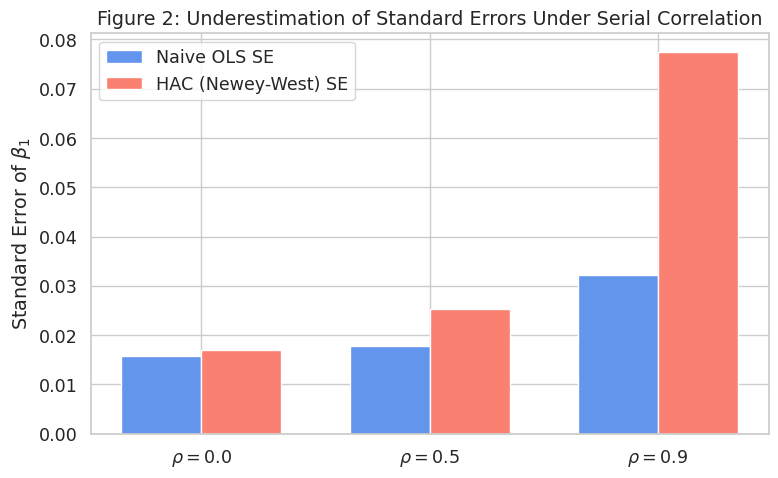

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Configure plotting environment for publication-quality figures
sns.set_theme(style="whitegrid", font_scale=1.15)
np.random.seed(42)

# =============================================================================
# 1. SYNTHETIC DATA GENERATION
# =============================================================================
n = 100
t = np.arange(n)
beta_0, beta_1 = 2.0, 1.0
sigma_u = 5.0  # Innovation standard deviation
rhos = [0.0, 0.5, 0.9]

def generate_ar1_errors(rho, n, sigma):
    """Generate AR(1) error terms: e_t = rho * e_{t-1} + u_t"""
    u = np.random.normal(0, sigma, n)
    e = np.zeros(n)
    e[0] = u[0]
    for i in range(1, n):
        e[i] = rho * e[i-1] + u[i]
    return e

# Create datasets for each correlation scenario
datasets = {}
for rho in rhos:
    errors = generate_ar1_errors(rho, n, sigma_u)
    y = beta_0 + beta_1 * t + errors
    datasets[rho] = pd.DataFrame({'time': t, 'response': y, 'true_errors': errors})

# =============================================================================
# 2. MODEL ESTIMATION (NAIVE OLS & CORRECTED HAC)
# =============================================================================
ols_results = {}
hac_results = {}

for rho in rhos:
    X = sm.add_constant(datasets[rho]['time'])
    y = datasets[rho]['response']
    
    # Naive OLS (assumes uncorrelated errors)
    ols_results[rho] = sm.OLS(y, X).fit()
    
    # OLS with HAC (Newey-West) standard errors to address serial correlation
    hac_results[rho] = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 10})

# =============================================================================
# 3. DIAGNOSTIC PLOTS: RESIDUALS VS. TIME
# =============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 4.5))
for i, rho in enumerate(rhos):
    res = ols_results[rho].resid
    axes1[i].plot(datasets[rho]['time'], res, marker='o', linestyle='-', 
                  markersize=4, color='steelblue', alpha=0.8)
    axes1[i].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
    axes1[i].set_title(f'OLS Residuals ($\\rho = {rho}$)')
    axes1[i].set_xlabel('Time Index')
    axes1[i].set_ylabel('Residual')
fig1.suptitle('Figure 1: Diagnostic Residual Plots Illustrating Tracking', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. QUANTIFYING THE CONSEQUENCES: STANDARD ERRORS & P-VALUES
# =============================================================================
# Extract statistics for the slope coefficient (time)
stats_df = pd.DataFrame({
    'Correlation ($\\rho$)': [f'{r}' for r in rhos],
    'Naive OLS SE': [ols_results[r].bse['time'] for r in rhos],
    'HAC Corrected SE': [hac_results[r].bse['time'] for r in rhos],
    'Naive OLS p-value': [ols_results[r].pvalues['time'] for r in rhos],
    'HAC Corrected p-value': [hac_results[r].pvalues['time'] for r in rhos]
})

print("Table 1: Impact of Error Correlation on Inference for β₁ (Time Slope)")
print(stats_df.to_string(index=False, formatters={
    'Correlation ($\\rho$)': '{:>5}'.format,
    'Naive OLS SE': '{:.4f}'.format,
    'HAC Corrected SE': '{:.4f}'.format,
    'Naive OLS p-value': '{:.4e}'.format,
    'HAC Corrected p-value': '{:.4e}'.format
}))

# Visualize SE inflation
fig2, ax2 = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(rhos))
width = 0.35
bars1 = ax2.bar(x_pos - width/2, stats_df['Naive OLS SE'], width, 
                label='Naive OLS SE', color='cornflowerblue')
bars2 = ax2.bar(x_pos + width/2, stats_df['HAC Corrected SE'], width, 
                label='HAC (Newey-West) SE', color='salmon')

ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'$\\rho={r}$' for r in rhos])
ax2.set_ylabel('Standard Error of $\\beta_1$')
ax2.set_title('Figure 2: Underestimation of Standard Errors Under Serial Correlation')
ax2.legend()
fig2.tight_layout()
plt.show()

# =============================================================================
# 5. ADDRESSING THE ISSUE: CORRECTED MODEL RESIDUALS (GLS/AR(1))
# =============================================================================
gls_results = {}
for rho in rhos:
    X = sm.add_constant(datasets[rho]['time'])
    y = datasets[rho]['response']
    
    # Estimate rho from OLS residuals for covariance structure
    e_ols = ols_results[rho].resid
    # Convert to NumPy arrays to prevent pandas index misalignment
    rho_hat = sm.OLS(e_ols.iloc[1:].to_numpy(), e_ols.iloc[:-1].to_numpy()).fit().params[0]
    
    # Construct AR(1) correlation matrix
    corr_mat = np.array([[rho_hat**abs(i-j) for j in range(n)] for i in range(n)])
    
    # Fit GLS with specified correlation structure
    gls_results[rho] = sm.GLS(y, X, sigma=corr_mat).fit()

Figure 1. shows the residuals over time between with three different levels of correlation between the predictor variables. We can see that as the correlation increses, the residuals begin to track more.

**Issue 2: Non-constant Variance of Error Terms**
***

Regression assumes that the variance of residuals is the same across all levels of predictor variables. Becuase calculations done with the regression model follow this assumption, the violation of it makes the outputs of the model unreliable. This can commonly be detected plotting the residuals against the fitted values and seeing if there is a funnel shape. If there is, then a common way to fix it is to transform the Y values. An example of this can be seen in the code section below.

a question that came up while reading that you couldn’t answer from the text alone, and the answer you investigated

While reading this rection I noticed that they only mentioned plotting against fitted values, which led me to wonder how we could detect if there was a predictor value causing the variance. I found that a common way of doing this is by plotting the residuals against each predictor seperately, similar to the above issue, and seeing if a funnel shape forms. Apparently this is primarily used to see which predictors may be driving the increase in variance.


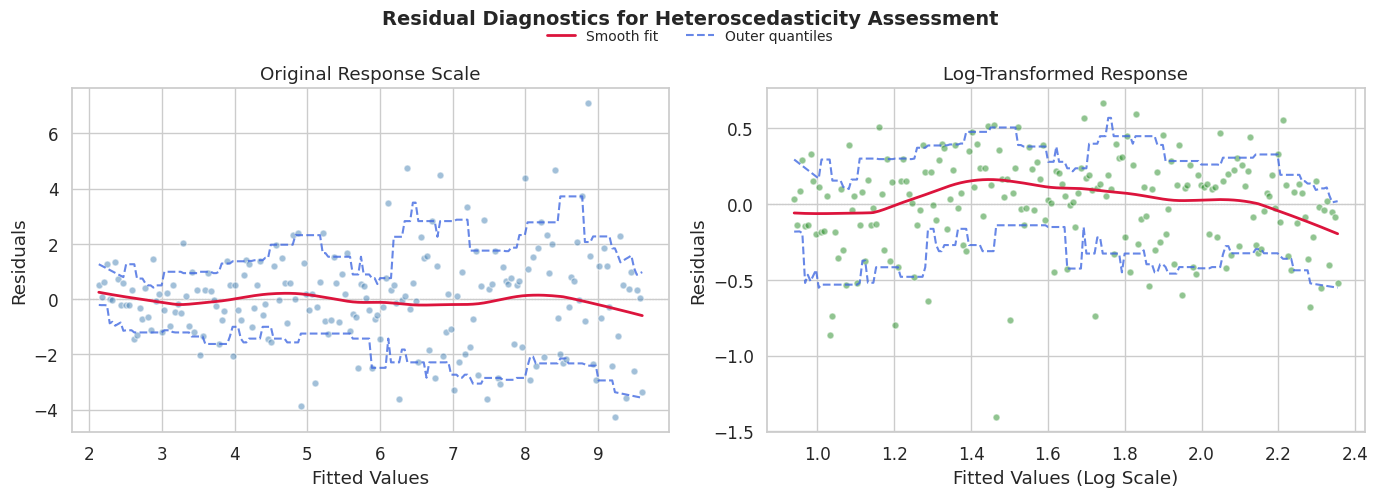

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

# Configure plotting environment
sns.set_theme(style="whitegrid", font_scale=1.1)
np.random.seed(42)

# =============================================================================
# 1. SYNTHETIC DATA GENERATION: HETEROSCEDASTIC ERRORS
# =============================================================================
n = 200
x = np.linspace(1, 10, n)
beta_0, beta_1 = 1.5, 0.8

# True conditional mean
mu = beta_0 + beta_1 * x

# Heteroscedastic errors: variance increases with expected response
sigma_base = 0.3
errors = np.random.normal(0, sigma_base * mu, n)
y = mu + errors

# =============================================================================
# 2. MODEL FITTING: ORIGINAL AND LOG-TRANSFORMED RESPONSE
# =============================================================================
X = sm.add_constant(x)

# OLS on original scale
ols_orig = sm.OLS(y, X).fit()
fitted_orig = ols_orig.fittedvalues
resid_orig = ols_orig.resid

# OLS on log-transformed response
y_log = np.log(y)
ols_log = sm.OLS(y_log, X).fit()
fitted_log = ols_log.fittedvalues
resid_log = ols_log.resid

# =============================================================================
# 3. HELPER FUNCTION: COMPUTE SMOOTH FIT AND OUTER QUANTILE BANDS
# =============================================================================
def add_residual_diagnostics(ax, fitted, resid, color='steelblue'):
    """Add LOWESS smooth and outer quantile bands to residual plot."""
    # Sort by fitted values for quantile calculation
    order = np.argsort(fitted)
    fitted_sorted = fitted[order]
    resid_sorted = resid[order]
    
    # LOWESS smooth (red line)
    lowess_result = lowess(resid, fitted, frac=0.3, return_sorted=True)
    ax.plot(lowess_result[:, 0], lowess_result[:, 1], 
            color='crimson', linewidth=2, label='Smooth fit')
    
    # Rolling outer quantiles (blue lines): 10th and 90th percentiles
    window = 20
    q_lower, q_upper = [], []
    x_plot = []
    for i in range(len(fitted_sorted)):
        start = max(0, i - window // 2)
        end = min(len(fitted_sorted), i + window // 2 + 1)
        q_lower.append(np.percentile(resid_sorted[start:end], 10))
        q_upper.append(np.percentile(resid_sorted[start:end], 90))
        x_plot.append(fitted_sorted[i])
    
    ax.plot(x_plot, q_lower, color='royalblue', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.plot(x_plot, q_upper, color='royalblue', linestyle='--', linewidth=1.5, alpha=0.8, label='Outer quantiles')
    
    # Scatter residuals
    ax.scatter(fitted, resid, alpha=0.5, color=color, edgecolors='white', s=25, zorder=1)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, zorder=0)

# =============================================================================
# 4. SINGLE FIGURE: TWO-PANEL RESIDUAL DIAGNOSTICS
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Original scale (heteroscedastic)
add_residual_diagnostics(axes[0], fitted_orig, resid_orig, color='steelblue')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Original Response Scale')

# Right panel: Log-transformed response (variance-stabilized)
add_residual_diagnostics(axes[1], fitted_log, resid_log, color='forestgreen')
axes[1].set_xlabel('Fitted Values (Log Scale)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Log-Transformed Response')

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
           ncol=2, frameon=False, fontsize=10)

fig.suptitle('Residual Diagnostics for Heteroscedasticity Assessment', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

**Issue 3: Collinearity**
***

a short paragraph explaining what the problem is, why it matters, and how to detect it (and how to address it, if applicable)

Colliniarity occures when the predictors are strongly correlated with one another, making it difficult to assess each predictors effect on the response. More specifically, this results in the accuracy of coefficient estimates decreasing and their standard errors increasing. Because the standard error increases, there is an increase in the Type II error (false negative) when testing if a coefficient is significant or not. To detect it you can either make a correlation matrix for two variables and look for large values, or for multicollinearity compute the variance inflation factor.

While this might sound. a bit dumb, while reading the text I found myself wondering what exactly the difference was between collinearity and the correlation of error terms as they seem somewhat similar conceptually. I found that the main distinction is that collinearity is about the inputs to the model, specifically when the X variables are correlated with eachother. In comparison, the correlation of error terms is primiarily about the outputs of the model, specifically when the variation the model could not account for is correlated across observations.

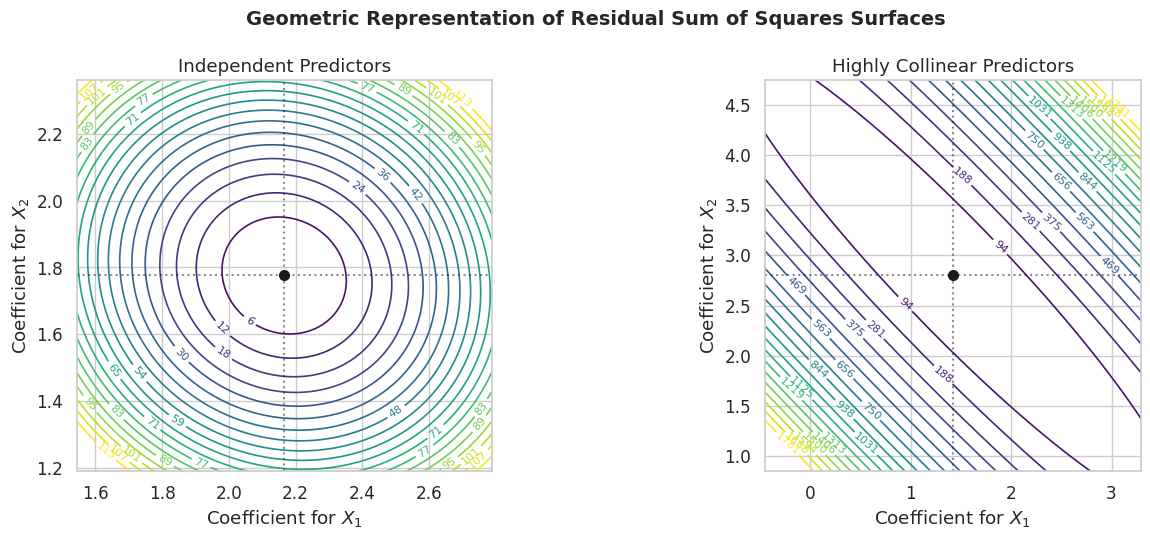


Table 1: Coefficient Uncertainty and Collinearity Diagnostics
                 Model  SE($\beta_1$)  SE($\beta_2$)  VIF($X_1$)  VIF($X_2$)
           Independent         0.1555         0.1467      1.0091      1.0091
      Collinear (Full)         0.4682         0.4873      9.1653      9.1653
Collinear (X2 Dropped)         0.1667            NaN      1.0000         NaN


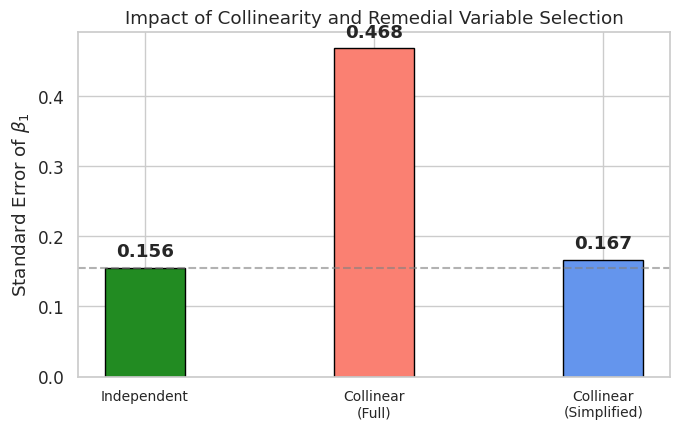

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configure plotting environment for formal presentation
sns.set_theme(style="whitegrid", font_scale=1.1)
np.random.seed(42)

# =============================================================================
# 1. SYNTHETIC DATA GENERATION
# =============================================================================
n = 200
x1 = np.random.normal(0, 1, n)

# Independent case: x2 uncorrelated with x1
x2_indep = np.random.normal(0, 1, n)

# Collinear case: x2 highly correlated with x1
x2_corr = 0.95 * x1 + np.random.normal(0, 0.3, n)

# True model: Y = 1.0 + 2.0*X1 + 2.0*X2 + noise
true_beta0, true_beta1, true_beta2 = 1.0, 2.0, 2.0
noise = np.random.normal(0, 2.0, n)
y_indep = true_beta0 + true_beta1 * x1 + true_beta2 * x2_indep + noise
y_corr = true_beta0 + true_beta1 * x1 + true_beta2 * x2_corr + noise

datasets = {
    'independent': pd.DataFrame({'x1': x1, 'x2': x2_indep, 'y': y_indep}),
    'collinear': pd.DataFrame({'x1': x1, 'x2': x2_corr, 'y': y_corr})
}

# =============================================================================
# 2. MODEL ESTIMATION
# =============================================================================
models = {}
for label, df in datasets.items():
    X = sm.add_constant(df[['x1', 'x2']])
    models[label] = sm.OLS(df['y'], X).fit()

# =============================================================================
# 3. RSS CONTOUR PLOTTING FUNCTION (CORRECTED BROADCASTING)
# =============================================================================
def compute_rss_grid(model, X, y, n_grid=100):
    """Compute RSS over a grid of (b1, b2) values centered at OLS estimates."""
    b1_hat, b2_hat = model.params['x1'], model.params['x2']
    se1, se2 = model.bse['x1'], model.bse['x2']
    beta0_hat = model.params['const']
    
    # Grid spans ±4 standard errors as described in the literature
    b1_vals = np.linspace(b1_hat - 4*se1, b1_hat + 4*se1, n_grid)
    b2_vals = np.linspace(b2_hat - 4*se2, b2_hat + 4*se2, n_grid)
    B1, B2 = np.meshgrid(b1_vals, b2_vals)
    
    X1 = np.asarray(X['x1']).flatten()
    X2 = np.asarray(X['x2']).flatten()
    y_vec = np.asarray(y).flatten()
    
    # Proper broadcasting: (n_grid, n_grid, 1) * (1, 1, n) -> (n_grid, n_grid, n)
    y_pred = beta0_hat + B1[:, :, None] * X1[None, None, :] + B2[:, :, None] * X2[None, None, :]
    RSS = np.sum((y_vec[None, None, :] - y_pred)**2, axis=2)
    return B1, B2, RSS

fig1, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for i, label in enumerate(['independent', 'collinear']):
    model = models[label]
    X = sm.add_constant(datasets[label][['x1', 'x2']])
    y = datasets[label]['y']
    
    B1, B2, RSS = compute_rss_grid(model, X, y)
    
    # Normalize RSS for comparable contour levels
    RSS_norm = RSS - RSS.min()
    
    # Plot contours
    max_val = np.percentile(RSS_norm, 98)
    levels = np.linspace(0, max_val, 20)
    contour = axes[i].contour(B1, B2, RSS_norm, levels=levels, cmap='viridis', linewidths=1.2)
    axes[i].clabel(contour, inline=True, fontsize=8, fmt='%1.0f')
    
    # Mark OLS estimate
    axes[i].plot(model.params['x1'], model.params['x2'], 'ko', markersize=7, zorder=5)
    axes[i].axvline(model.params['x1'], color='k', linestyle=':', alpha=0.5)
    axes[i].axhline(model.params['x2'], color='k', linestyle=':', alpha=0.5)
    
    axes[i].set_xlabel('Coefficient for $X_1$')
    axes[i].set_ylabel('Coefficient for $X_2$')
    axes[i].set_title('Independent Predictors' if i == 0 else 'Highly Collinear Predictors')
    axes[i].set_aspect('equal')

fig1.suptitle('Geometric Representation of Residual Sum of Squares Surfaces', 
              fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. DIAGNOSTICS & REMEDIAL COMPARISON
# =============================================================================
def compute_vifs(X):
    exog = sm.add_constant(X)
    return [variance_inflation_factor(exog.values, i) for i in range(1, exog.shape[1])]

vif_indep = compute_vifs(datasets['independent'][['x1', 'x2']])
vif_corr = compute_vifs(datasets['collinear'][['x1', 'x2']])

# Solution: Drop X2 from collinear model
X_corr_drop = sm.add_constant(datasets['collinear']['x1'])
model_solved = sm.OLS(datasets['collinear']['y'], X_corr_drop).fit()

# Compile comparison data
comp_data = pd.DataFrame({
    'Model': ['Independent', 'Collinear (Full)', 'Collinear (X2 Dropped)'],
    'SE($\\beta_1$)': [models['independent'].bse['x1'], models['collinear'].bse['x1'], model_solved.bse['x1']],
    'SE($\\beta_2$)': [models['independent'].bse['x2'], models['collinear'].bse['x2'], np.nan],
    'VIF($X_1$)': [vif_indep[0], vif_corr[0], 1.0],
    'VIF($X_2$)': [vif_indep[1], vif_corr[1], np.nan]
})

print("\nTable 1: Coefficient Uncertainty and Collinearity Diagnostics")
print(comp_data.to_string(index=False, float_format='%.4f'))

# Visualization of standard error inflation and correction
fig2, ax = plt.subplots(figsize=(7, 4.5))
x_pos = np.arange(3)
width = 0.35
se_vals = comp_data['SE($\\beta_1$)'].values
bars = ax.bar(x_pos, se_vals, width, color=['forestgreen', 'salmon', 'cornflowerblue'], edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Independent', 'Collinear\n(Full)', 'Collinear\n(Simplified)'], fontsize=10)
ax.set_ylabel('Standard Error of $\\beta_1$')
ax.set_title('Impact of Collinearity and Remedial Variable Selection')
for bar, val in zip(bars, se_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.axhline(models['independent'].bse['x1'], color='gray', linestyle='--', alpha=0.6)
fig2.tight_layout()
plt.show()

The first figure shows a contour plots of the residual sum of squares (RSS) surface across possible values for the coefficients of two predictor variables. We can see that when the predictors are independent the model can cleanly estimate the effect as indicated by the tight circles around the LSE. However when they are highly correlated the model struggles to seperate them resulting in the 'valley' of possible answers.

### Reflection
***

For this assignment I used Qwen, a lesser known Chinese model, and pretty much just copied what the assignment said to do along with the the text from the book and let it figure the rest out. I tested this out on the Kimi model as well, but found that while it worked better the response For each of the plots it took two iterations as the code would run but give errors.